### Упражнение 1

- Рассмотрим в качестве сезонной составляющей периодический сигнал с периодом 12
```python
time = np.arange(144)
seasonal_12 = 20 + np.sin(2*np.pi*time/12)*20
```
- Используйте `seasonal_12` и компоненты `trend` и `residual` ниже, чтобы определить и построить аддитивную и мультипликативную модели
```python
trend = time * 2.65 + 100
residuals = np.random.normal(loc=0.0, scale=3, size=len(time))
```
- Выполните сезонную декомпозицию с `seasonal_decompose` и `STL` для новых сигналов и сравните результаты с полученными в классе, где мы использовали приблизительный период.
### Упражнение 2
Загрузите два разных временных ряда следующим образом.
```python
import statsmodels.api as sm
ts_A = sm.datasets.get_rdataset("AirPassengers", "datasets").data["value"].values
print(len(ts_A))
ts_B = sm.datasets.get_rdataset("co2", "datasets").data["value"].values
print(len(ts_B))
```
- Постройте график двух временных рядов.
- Определите, выглядит ли временной ряд аддитивной или мультипликативной моделью.
- Определите основной период сезонной составляющей в двух временных рядах.
### Упражнение 3
- Разложите `ts_A` и `ts_B` с помощью `seasonal_decompose` и `STL`.
- Прокомментируйте полученные результаты.
from statsmodels.tsa.seasonal import season_decompose, STL

#### Импорты

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

import statsmodels.api as sm


### Упражнение 1

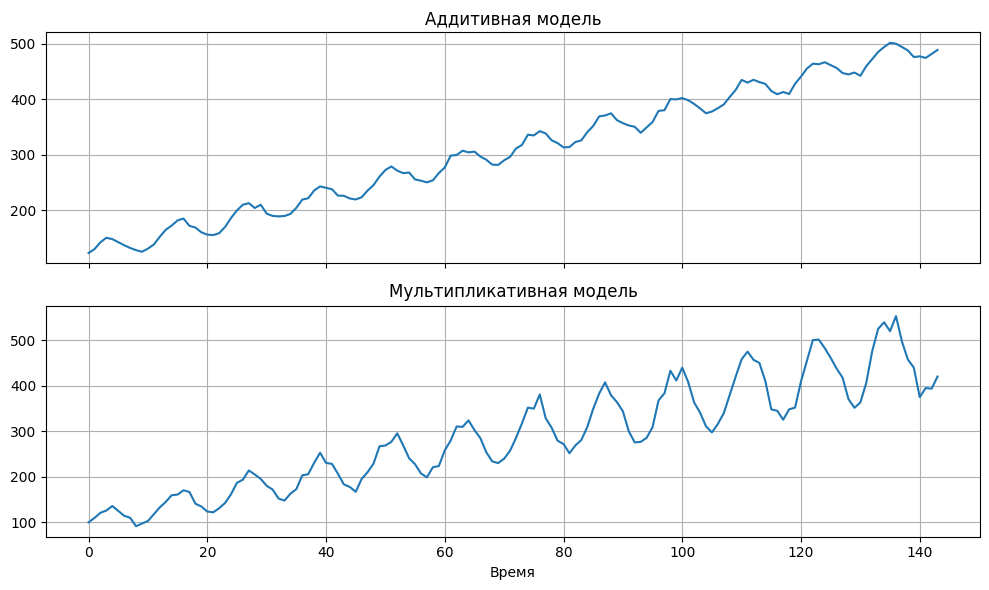

In [10]:
time = np.arange(144)
seasonal_12 = 20 + np.sin(2*np.pi*time/12)*20  # период = 12
trend = time * 2.65 + 100
residuals = np.random.normal(loc=0.0, scale=3, size=len(time))

#Аддитивная модель
additive_model = trend + seasonal_12 + residuals

#Мультипликативная модель
seasonal_12_mult = 1 + np.sin(2*np.pi*time/12)*0.2
residuals_mult = np.random.normal(loc=1.0, scale=0.03, size=len(time))
multiplicative_model = trend * seasonal_12_mult * residuals_mult

#Декомпозиция
decomp_add = seasonal_decompose(additive_model, model='additive', period=12)
decomp_mult = seasonal_decompose(multiplicative_model, model='multiplicative', period=12)
stl_add = STL(additive_model, period=12).fit()

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(time, additive_model)
ax[0].set_title("Аддитивная модель")
ax[0].grid(True)

ax[1].plot(time, multiplicative_model)
ax[1].set_title("Мультипликативная модель")
ax[1].set_xlabel("Время")
ax[1].grid(True)

plt.tight_layout()
plt.show()

### Упражнение 2

In [13]:
import statsmodels.api as sm

ts_A = sm.datasets.get_rdataset("AirPassengers", "datasets").data["value"].values
ts_B = sm.datasets.co2.load_pandas().data['co2'].values

print(f"ts_A: {len(ts_A)}, ts_B: {len(ts_B)}")

ts_A: 144, ts_B: 2284


### Упражнение 3

In [15]:
ts_A = sm.datasets.get_rdataset("AirPassengers", "datasets").data["value"].values
ts_B = sm.datasets.co2.load_pandas().data['co2'].dropna().values

print(f"ts_A: {len(ts_A)}, ts_B: {len(ts_B)}")

ts_A: 144, ts_B: 2225


Мультипликативная модель лучше описывает данные AirPassengers, так как амплитуда сезонности растет вместе с трендом

Аддитивная модель идеально подходит для данных со2 с постоянной амплитудой сезонности